# 1.3b Trip Data Quality Check

Full post-cleaning audit of `data/trips/01_04_trips_clean.parquet`: missing values, empty strings, distributions, consistency checks, and anything noteworthy that may have slipped through cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import os

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print("Working directory:", os.getcwd())

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

Working directory: /Users/hendrik/Coding/Master/AAA


In [2]:
df = pd.read_parquet("data/trips/01_04_trips_clean.parquet")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.info()

Shape: 5,369,356 rows  x  23 columns
Memory: 2.35 GB
<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_community_area       int64         
 7   dropoff_community_area      int64         
 8   fare                        float64       
 9   tips                        float64       
 10  tolls                       float64       
 11  extras                      float64       
 12  trip_total                  float64       
 13  payment_type                str           
 14  company                     str           
 15  pickup_centroid_latitude

## 1  Missing & Empty Values

In [3]:
n = len(df)

# NaN / None / pd.NA
null_counts = df.isna().sum()

# Empty strings and whitespace-only strings for object columns
str_cols = df.select_dtypes(include="object").columns
empty_str_counts = pd.Series(0, index=df.columns)
for col in str_cols:
    empty_str_counts[col] = (df[col].astype(str).str.strip() == "").sum()

# "NA" / "nan" / "null" as literal strings
literal_na_counts = pd.Series(0, index=df.columns)
for col in str_cols:
    literal_na_counts[col] = df[col].astype(str).str.lower().isin(["na", "nan", "null", "none", "<na>"]).sum()

summary = pd.DataFrame({
    "NaN/None": null_counts,
    "Empty string": empty_str_counts,
    "Literal 'na'/'nan'": literal_na_counts,
})
summary["Total missing"] = summary.sum(axis=1)
summary["% of rows"] = (summary["Total missing"] / n * 100).round(3)
print(summary[summary["Total missing"] > 0].to_string())
print()
print("Columns with ZERO missing values:")
print(list(summary[summary["Total missing"] == 0].index))

/var/folders/cn/fgq6fx4941j6hk598s_2v6t00000gn/T/ipykernel_7341/4239546399.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


         NaN/None  Empty string  Literal 'na'/'nan'  Total missing  % of rows
taxi_id         0             4                   0              4        0.0

Columns with ZERO missing values:
['trip_id', 'trip_start_timestamp', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'pickup_community_area', 'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras', 'trip_total', 'payment_type', 'company', 'pickup_centroid_latitude', 'pickup_centroid_longitude', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'pickup_h3_res6', 'dropoff_h3_res6', 'pickup_h3_res7', 'dropoff_h3_res7']


In [4]:
# Coordinate NaN breakdown: pickup vs dropoff
print("Coordinate NaN detail:")
for side in ("pickup", "dropoff"):
    lat_na = df[f"{side}_centroid_latitude"].isna().sum()
    lon_na = df[f"{side}_centroid_longitude"].isna().sum()
    both_na = (df[f"{side}_centroid_latitude"].isna() & df[f"{side}_centroid_longitude"].isna()).sum()
    lat_only = lat_na - both_na
    lon_only = lon_na - both_na
    print(f"  {side}: lat_na={lat_na:,}  lon_na={lon_na:,}  both_na={both_na:,}  lat_only={lat_only}  lon_only={lon_only}")

Coordinate NaN detail:
  pickup: lat_na=0  lon_na=0  both_na=0  lat_only=0  lon_only=0
  dropoff: lat_na=0  lon_na=0  both_na=0  lat_only=0  lon_only=0


## 2  Numeric Column Distributions & Outliers

In [5]:
numeric_cols = ["trip_seconds", "trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]

desc = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc["skew"] = df[numeric_cols].skew().round(2)
desc["zeros"] = (df[numeric_cols] == 0).sum()
desc["negatives"] = (df[numeric_cols] < 0).sum()
print(desc.to_string())

                  count         mean         std     min      1%      5%     25%     50%      75%      95%      99%      max   skew    zeros  negatives
trip_seconds  5369356.0  1186.536795  857.587958  194.00  226.00  300.00  540.00  905.00  1593.00  3013.00  3954.00  4543.00   1.34        0          0
trip_miles    5369356.0     6.468115    6.197436    0.34    0.48    0.70    1.42    3.33    11.30    17.95    21.25    43.71   0.94        0          0
fare          5369356.0    20.422245   14.689471    3.75    5.00    5.75    8.50   13.75    30.75    46.50    62.30    76.58   0.96        0          0
tips          5369356.0     2.428965    3.582384    0.00    0.00    0.00    0.00    0.00     3.20    10.10    13.38    21.90   1.59  2869932          0
tolls         5369356.0     0.006984    0.173972    0.00    0.00    0.00    0.00    0.00     0.00     0.00     0.00    25.00  43.24  5355257          0
extras        5369356.0     1.022702    1.999676    0.00    0.00    0.00    0.00    0.00

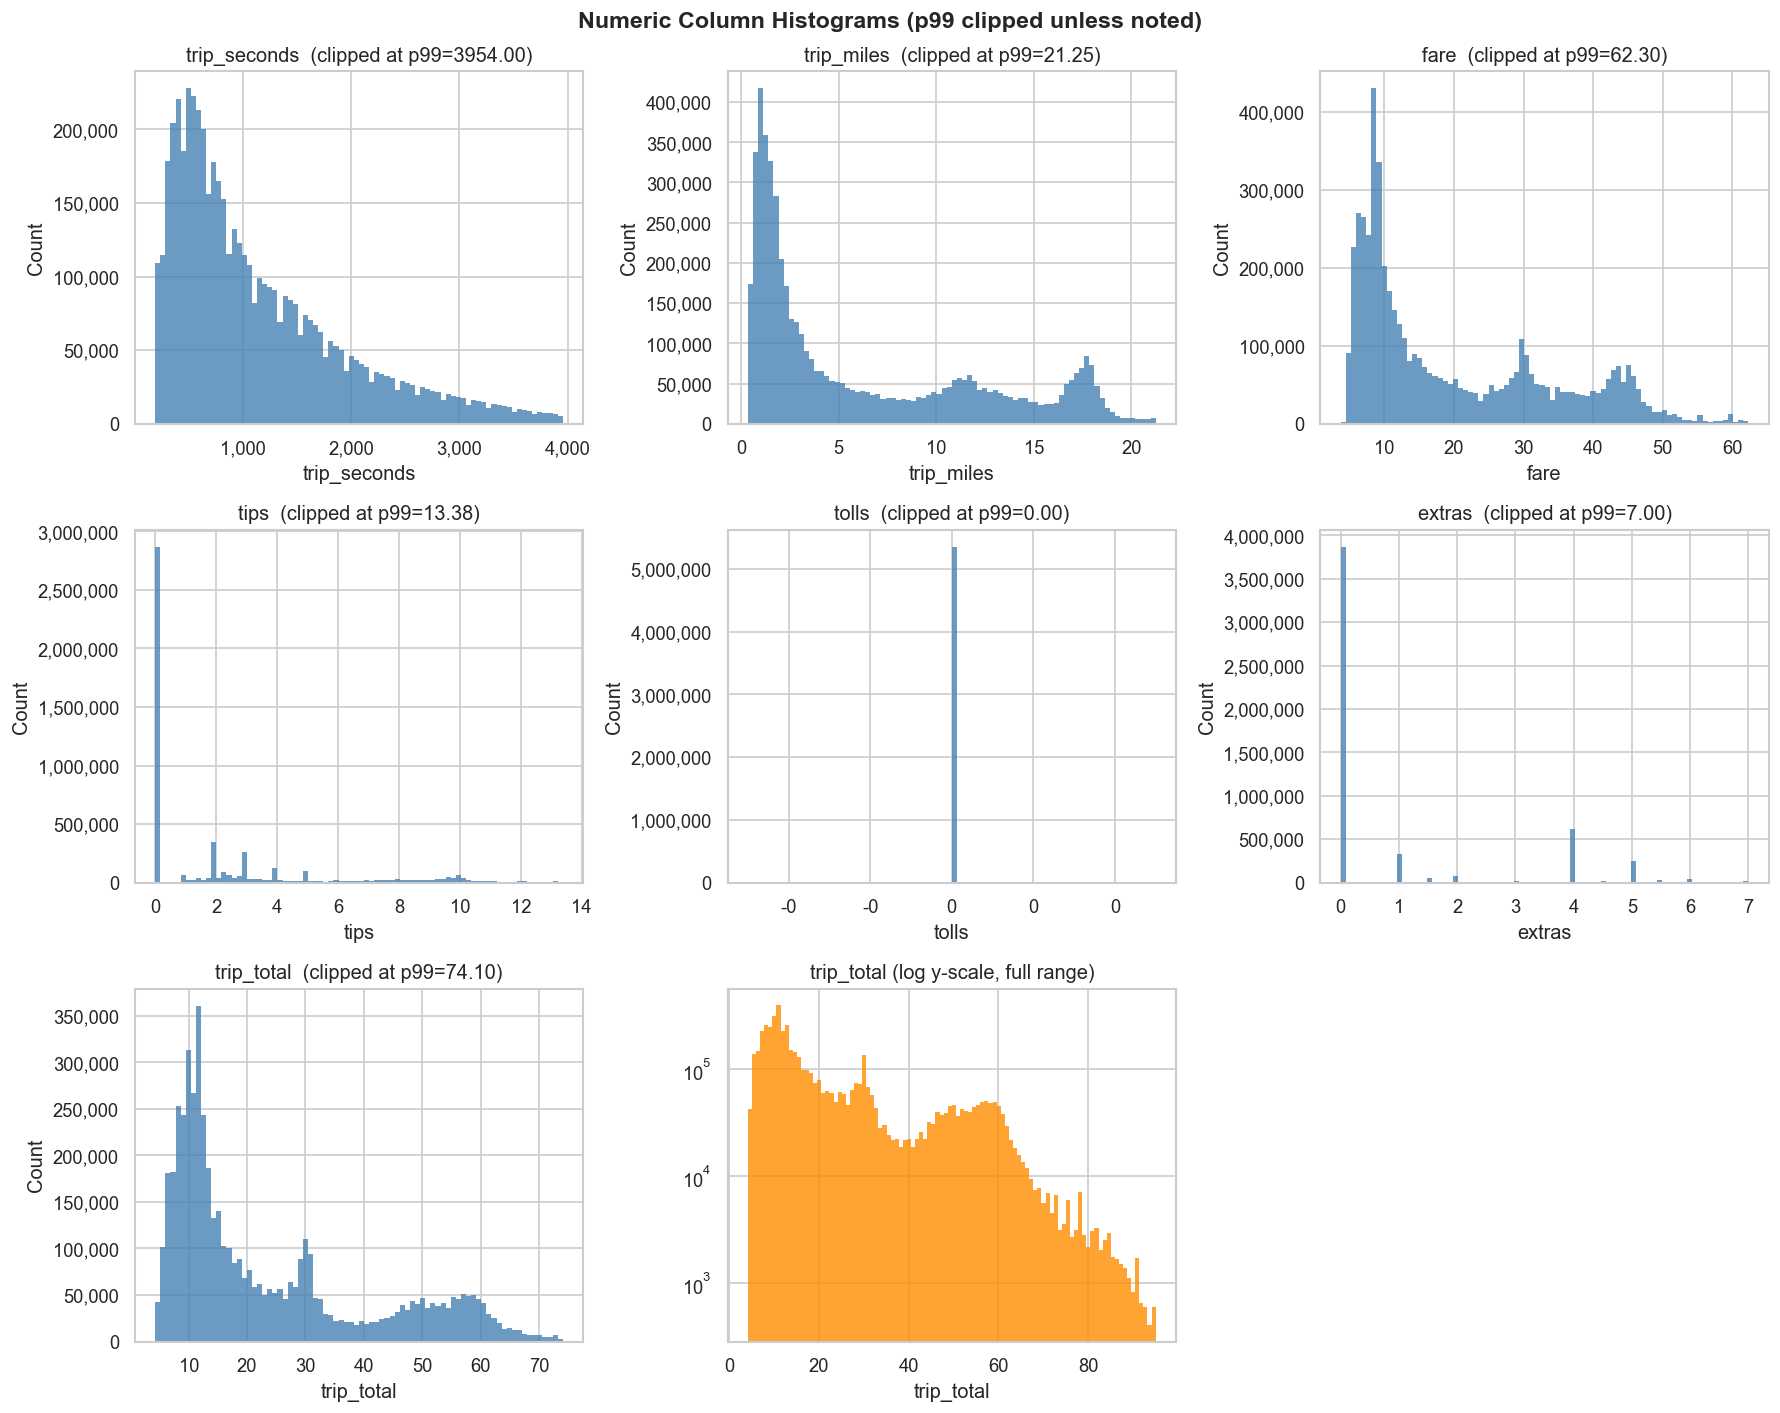

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    q99 = data.quantile(0.99)
    clipped = data[data <= q99]
    axes[i].hist(clipped, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].set_title(f"{col}  (clipped at p99={q99:.2f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Use last subplot for trip_total log-scale
ax_log = axes[len(numeric_cols)]
ax_log.hist(df["trip_total"].dropna(), bins=100, color="darkorange", edgecolor="none", alpha=0.8)
ax_log.set_yscale("log")
ax_log.set_title("trip_total (log y-scale, full range)")
ax_log.set_xlabel("trip_total")

for j in range(len(numeric_cols) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Column Histograms (p99 clipped unless noted)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

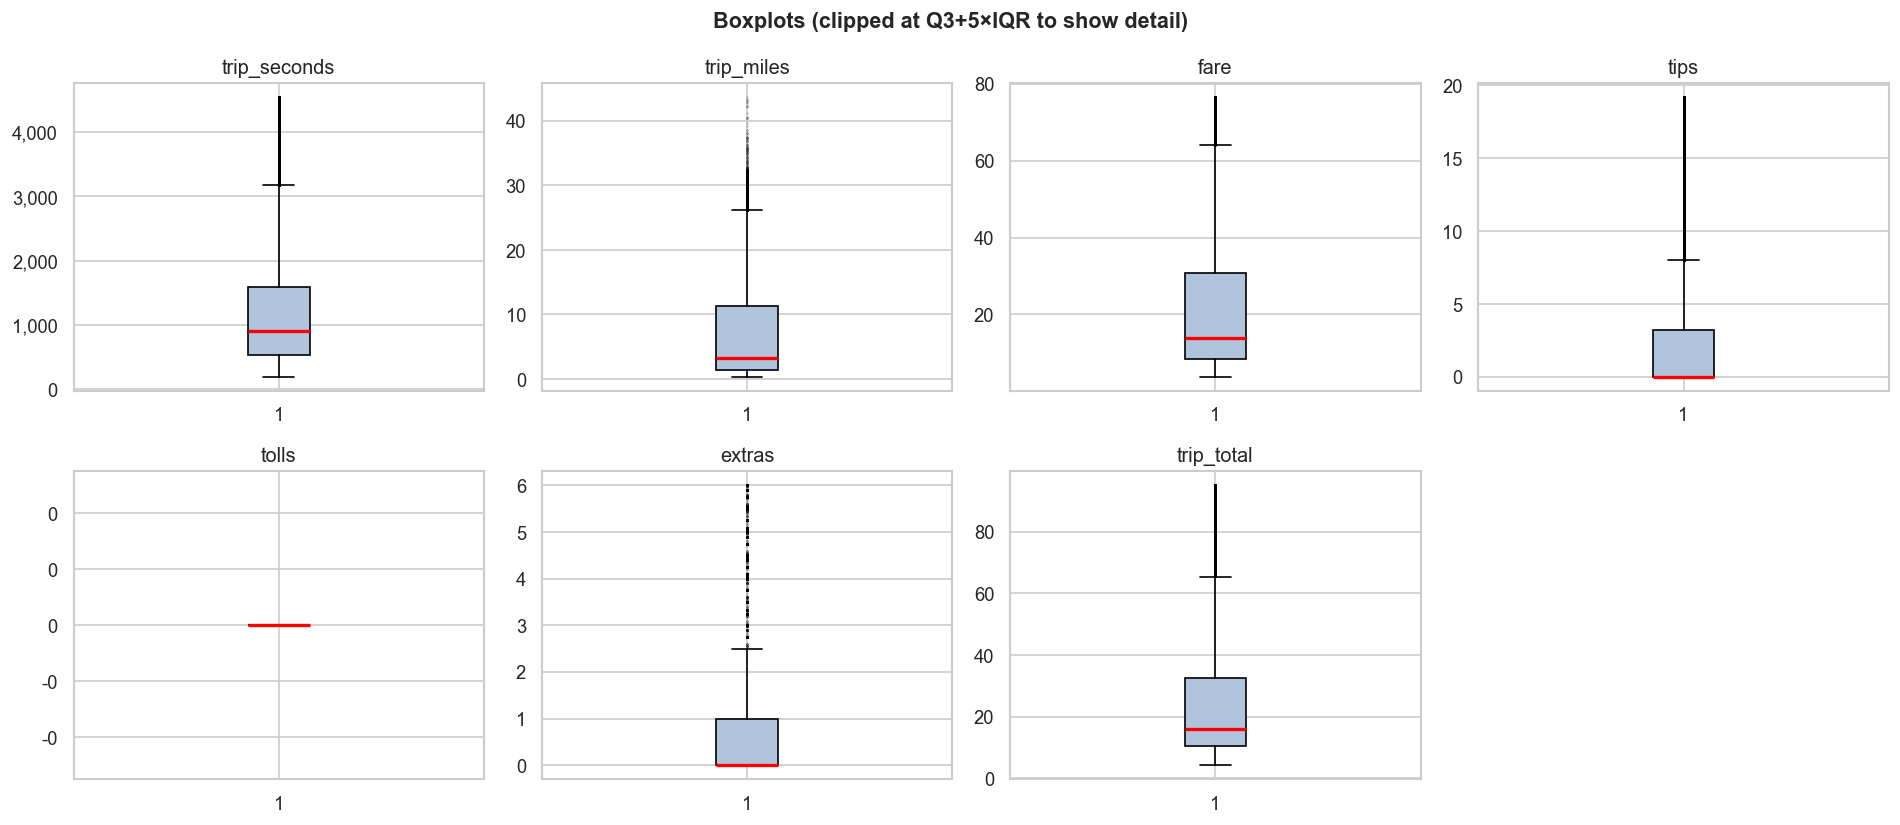

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    axes[i].boxplot(data.clip(upper=q3 + 5 * iqr), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightsteelblue"),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker=".", markersize=1, alpha=0.2))
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots (clipped at Q3+5×IQR to show detail)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3  Derived Metrics: Speed & Fare Rate

In [8]:
df["speed_mph"] = df["trip_miles"] / (df["trip_seconds"] / 3600)
df["fare_per_mile"] = df["fare"] / df["trip_miles"]
df["trip_minutes"] = df["trip_seconds"] / 60

print("Speed (mph) stats:")
print(df["speed_mph"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(2))
print()

suspicious_speed = df[df["speed_mph"] > 80]
print(f"Trips with speed > 80 mph: {len(suspicious_speed):,}  ({len(suspicious_speed)/n*100:.3f}%)")
print(suspicious_speed[["trip_seconds", "trip_miles", "speed_mph", "fare"]].describe().round(2))
print()

print("Fare per mile stats:")
print(df["fare_per_mile"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(2))

# Implausibly high fare/mile could mean very short trips billed at minimum
high_fare_rate = df[df["fare_per_mile"] > 50]
print(f"\nTrips with fare_per_mile > $50: {len(high_fare_rate):,}  ({len(high_fare_rate)/n*100:.3f}%)")
print(high_fare_rate[["trip_miles", "trip_seconds", "fare", "fare_per_mile"]].head(10).to_string())

Speed (mph) stats:
count    5369356.00
mean          17.25
std           10.69
min            0.29
1%             3.93
5%             5.91
25%            9.11
50%           13.55
75%           23.36
95%           39.11
99%           49.02
max          356.59
Name: speed_mph, dtype: float64

Trips with speed > 80 mph: 187  (0.003%)
       trip_seconds  trip_miles  speed_mph    fare
count        187.00      187.00     187.00  187.00
mean         505.72       17.03     140.50   26.81
std          284.15        6.50      66.16   17.05
min          194.00        5.70      80.02    4.50
25%          303.00       12.90      88.25    9.50
50%          457.00       16.33     118.00   29.00
75%          577.00       19.55     173.16   39.00
max         1800.00       43.10     356.59   75.00

Fare per mile stats:
count    5369356.00
mean           4.80
std            3.02
min            0.22
1%             2.43
5%             2.49
25%            2.74
50%            3.98
75%            5.95
95%   

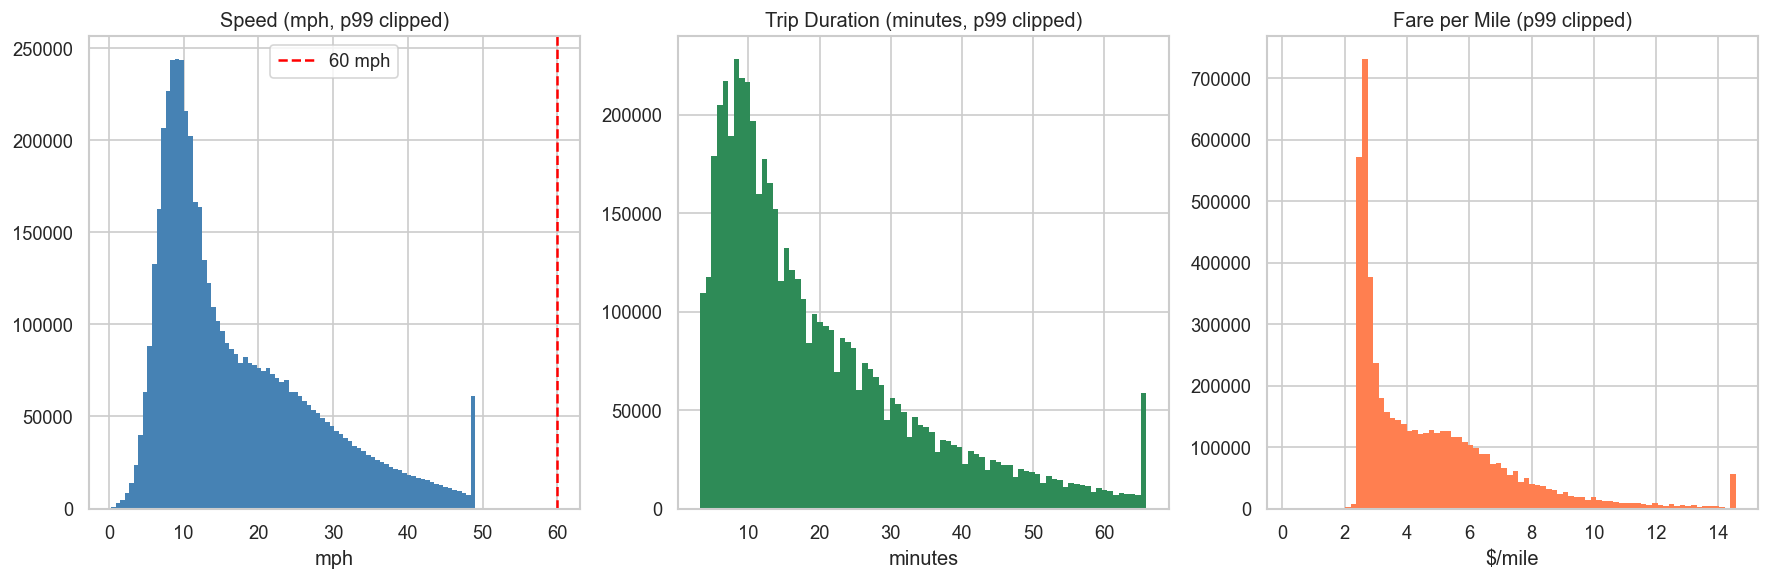

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Speed distribution
speed_clipped = df["speed_mph"].clip(upper=df["speed_mph"].quantile(0.99))
axes[0].hist(speed_clipped, bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Speed (mph, p99 clipped)")
axes[0].set_xlabel("mph")
axes[0].axvline(60, color="red", linestyle="--", label="60 mph")
axes[0].legend()

# Trip duration in minutes
mins_clipped = df["trip_minutes"].clip(upper=df["trip_minutes"].quantile(0.99))
axes[1].hist(mins_clipped, bins=80, color="seagreen", edgecolor="none")
axes[1].set_title("Trip Duration (minutes, p99 clipped)")
axes[1].set_xlabel("minutes")

# Fare per mile
fpm_clipped = df["fare_per_mile"].clip(upper=df["fare_per_mile"].quantile(0.99))
axes[2].hist(fpm_clipped, bins=80, color="coral", edgecolor="none")
axes[2].set_title("Fare per Mile (p99 clipped)")
axes[2].set_xlabel("$/mile")

plt.tight_layout()
plt.show()

## 4  Cross-Column Consistency Checks

In [10]:
# 4a) trip_total vs. sum of components
df["expected_total"] = df["fare"] + df["tips"] + df["tolls"] + df["extras"]
df["total_diff"] = (df["trip_total"] - df["expected_total"]).round(2)

print("trip_total - (fare+tips+tolls+extras):")
print(df["total_diff"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(4))
print()

tol = 0.05  # $0.05 tolerance for rounding
mismatch = df[df["total_diff"].abs() > tol]
print(f"Trips where |trip_total - sum| > ${tol}: {len(mismatch):,}  ({len(mismatch)/n*100:.2f}%)")
print()
print("Worst mismatches (top 10 by absolute diff):")
print(mismatch[["fare", "tips", "tolls", "extras", "trip_total", "expected_total", "total_diff"]]
      .reindex(mismatch["total_diff"].abs().nlargest(10).index)
      .to_string())

trip_total - (fare+tips+tolls+extras):
count    5.369356e+06
mean     2.999000e-01
std      3.386000e-01
min     -0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      0.000000e+00
50%      5.000000e-01
75%      5.000000e-01
95%      5.000000e-01
99%      5.000000e-01
max      3.500000e+00
Name: total_diff, dtype: float64

Trips where |trip_total - sum| > $0.05: 3,016,169  (56.17%)

Worst mismatches (top 10 by absolute diff):
         fare   tips  tolls  extras  trip_total  expected_total  total_diff
131138  14.50   4.19    0.0     0.0       22.19           18.69         3.5
131241  14.94   4.38    0.0     0.0       22.82           19.32         3.5
131262  44.50  10.50    0.0     0.0       58.50           55.00         3.5
131708  14.50   3.12    0.0     0.0       21.12           17.62         3.5
131713  25.48   6.32    0.0     0.0       35.30           31.80         3.5
131993  48.63   3.00    0.0     0.0       55.13           51.63         3.5
133462  14.50   2.16    0.

In [11]:
# 4b) Timestamps: end < start (negative duration), very long trips, trips ending in 2026
bad_ts = df[df["trip_end_timestamp"] < df["trip_start_timestamp"]]
print(f"Trips where end < start:  {len(bad_ts):,}")

same_ts = df[df["trip_end_timestamp"] == df["trip_start_timestamp"]]
print(f"Trips where end == start: {len(same_ts):,}  (trip_seconds={same_ts['trip_seconds'].describe().to_dict()})")

end_2026 = df[df["trip_end_timestamp"].dt.year == 2026]
print(f"Trips ending in 2026:     {len(end_2026):,}")
print(end_2026[["trip_start_timestamp", "trip_end_timestamp", "trip_seconds", "trip_miles"]].head(5).to_string())

very_long = df[df["trip_seconds"] > 10 * 3600]  # > 10 hours
print(f"\nTrips > 10 hours: {len(very_long):,}")
print(very_long[["trip_seconds", "trip_miles", "fare"]].describe().round(2))

Trips where end < start:  0
Trips where end == start: 1,042,361  (trip_seconds={'count': 1042361.0, 'mean': 449.10877133737733, 'std': 154.03172258725633, 'min': 194.0, '25%': 325.0, '50%': 427.0, '75%': 553.0, 'max': 4269.0})
Trips ending in 2026:     72
        trip_start_timestamp  trip_end_timestamp  trip_seconds  trip_miles
5369146  2025-12-31 23:15:00 2026-01-01 00:00:00        2558.0        2.52
5369159  2025-12-31 23:15:00 2026-01-01 00:00:00        2291.0        0.64
5369170  2025-12-31 23:15:00 2026-01-01 00:00:00        2574.0       18.15
5369176  2025-12-31 23:15:00 2026-01-01 00:00:00        2337.0        0.78
5369180  2025-12-31 23:15:00 2026-01-01 00:30:00        4493.0       10.96

Trips > 10 hours: 0
       trip_seconds  trip_miles  fare
count           0.0         0.0   0.0
mean            NaN         NaN   NaN
std             NaN         NaN   NaN
min             NaN         NaN   NaN
25%             NaN         NaN   NaN
50%             NaN         NaN   NaN
75%    

In [12]:
# 4c) Tips > fare (unusually generous or data artifact?)
tip_gt_fare = df[df["tips"] > df["fare"]]
print(f"Trips where tip > fare: {len(tip_gt_fare):,}  ({len(tip_gt_fare)/n*100:.3f}%)")
print(tip_gt_fare[["fare", "tips", "trip_total", "payment_type"]].describe().round(2))
print()
print("Payment type breakdown for tip > fare trips:")
print(tip_gt_fare["payment_type"].value_counts())
print()

# 4d) Same pickup and dropoff community area but > 5 miles
same_ca_long = df[(df["pickup_community_area"] == df["dropoff_community_area"]) & (df["trip_miles"] > 5)]
print(f"Same pickup=dropoff CA but trip_miles > 5: {len(same_ca_long):,}  ({len(same_ca_long)/n*100:.3f}%)")
print(same_ca_long[["pickup_community_area", "trip_miles", "trip_seconds", "fare"]].describe().round(2))

# 4e) Exact same pickup + dropoff coordinates (zero displacement, trip_miles > 0)
same_coords = df[
    (df["pickup_centroid_latitude"] == df["dropoff_centroid_latitude"]) &
    (df["pickup_centroid_longitude"] == df["dropoff_centroid_longitude"]) &
    (df["trip_miles"] > 0) &
    df["pickup_centroid_latitude"].notna()
]
print(f"\nSame exact coordinates but trip_miles > 0: {len(same_coords):,}  ({len(same_coords)/n*100:.3f}%)")
print(same_coords[["trip_miles", "trip_seconds", "fare"]].describe().round(2))

Trips where tip > fare: 8,090  (0.151%)
          fare     tips  trip_total
count  8090.00  8090.00     8090.00
mean      7.88    11.08       20.12
std       2.48     3.76        6.11
min       3.75     4.00        9.25
25%       6.00    10.00       16.25
50%       7.50    10.00       19.00
75%       9.00    12.00       22.50
max      21.25    21.75       50.50

Payment type breakdown for tip > fare trips:
payment_type
Credit Card    6373
Mobile         1655
Prcard           42
Cash             20
Name: count, dtype: int64

Same pickup=dropoff CA but trip_miles > 5: 18,352  (0.342%)
       pickup_community_area  trip_miles  trip_seconds      fare
count               18352.00    18352.00      18352.00  18352.00
mean                   54.11       10.14       1957.54     29.55
std                    27.60        5.16        958.34     12.07
min                     1.00        5.01        198.00      4.50
25%                    32.00        6.10       1167.00     20.00
50%                 

## 5  Temporal Patterns

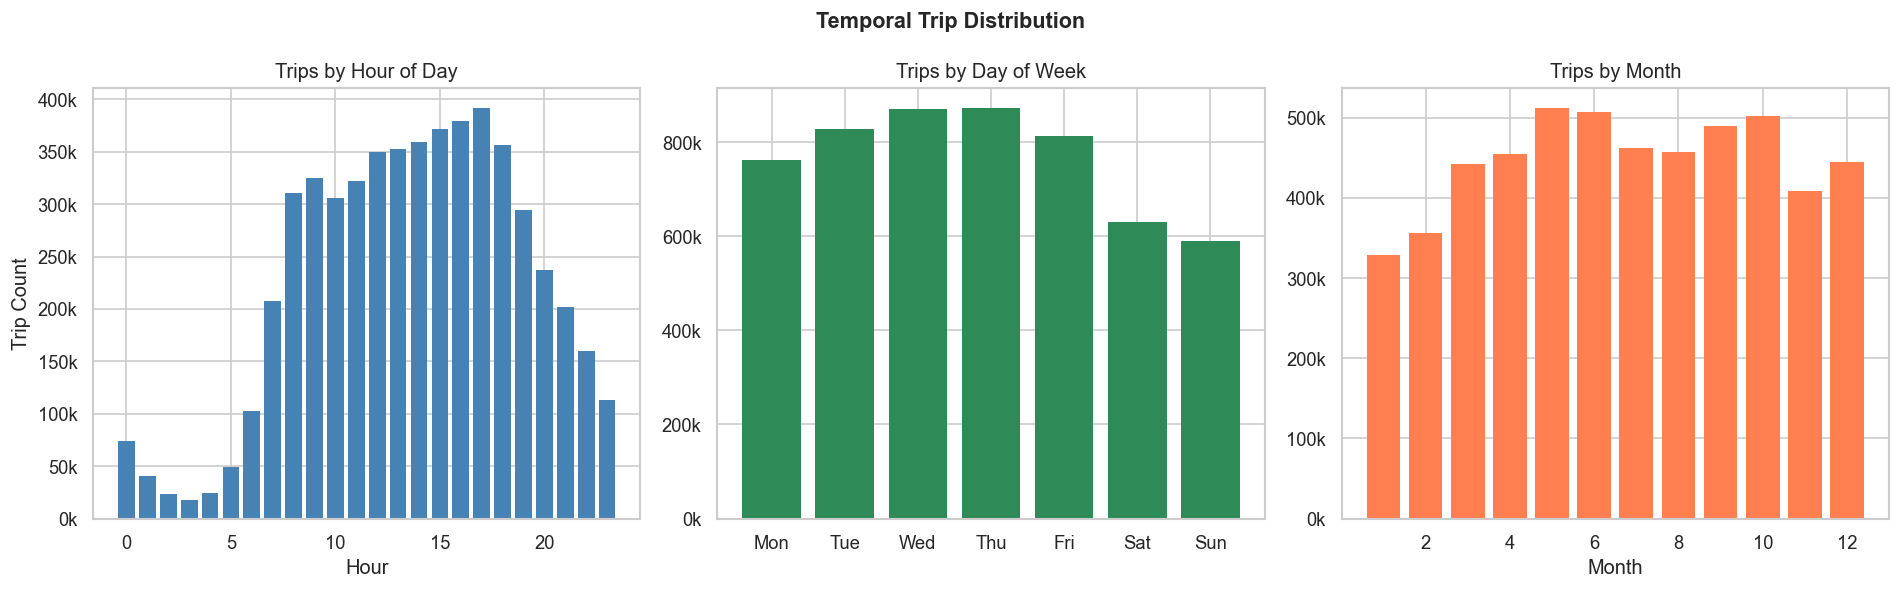

In [13]:
df["hour"] = df["trip_start_timestamp"].dt.hour
df["dayofweek"] = df["trip_start_timestamp"].dt.dayofweek  # 0=Mon
df["month"] = df["trip_start_timestamp"].dt.month
df["date"] = df["trip_start_timestamp"].dt.date

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trips by hour of day
hourly = df.groupby("hour").size()
axes[0].bar(hourly.index, hourly.values, color="steelblue", edgecolor="none")
axes[0].set_title("Trips by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Trip Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Trips by day of week
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df.groupby("dayofweek").size()
axes[1].bar(dow.index, dow.values, color="seagreen", edgecolor="none")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].set_title("Trips by Day of Week")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Trips by month
monthly = df.groupby("month").size()
axes[2].bar(monthly.index, monthly.values, color="coral", edgecolor="none")
axes[2].set_title("Trips by Month")
axes[2].set_xlabel("Month")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

plt.suptitle("Temporal Trip Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

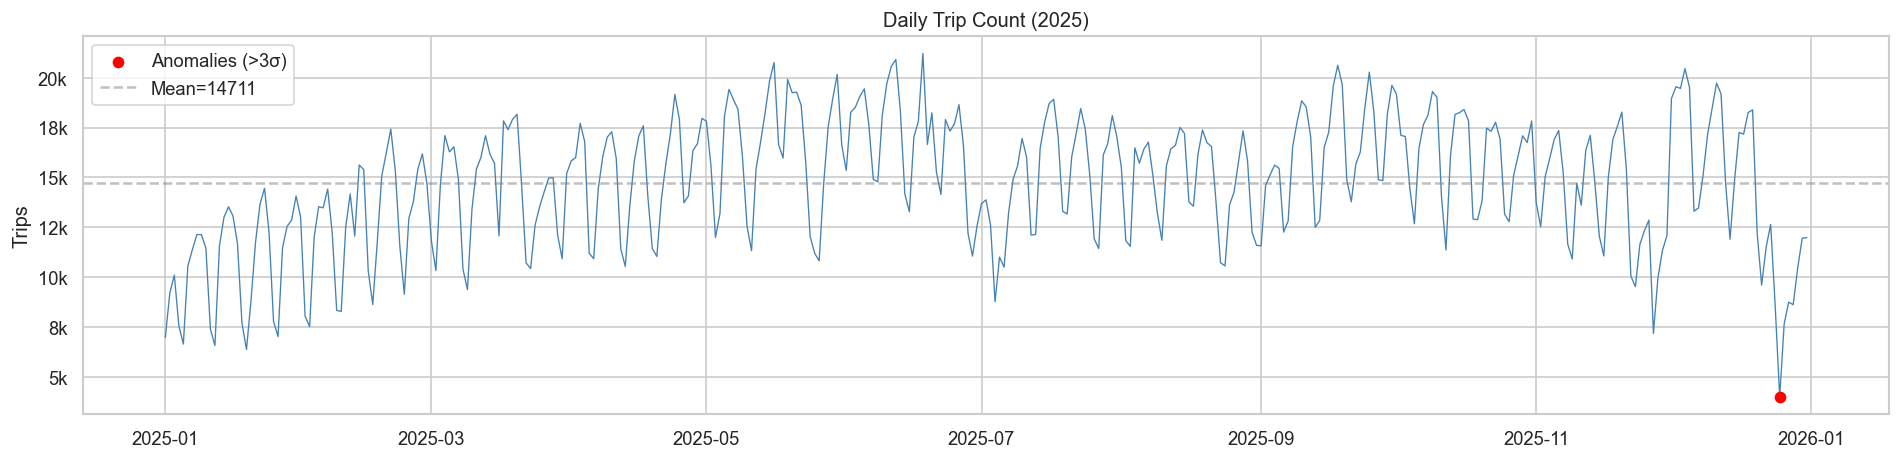

Anomalous days:
          date  trips
358 2025-12-25   3992


In [14]:
# Daily trip volume — look for unusual drops or spikes
daily = df.groupby("date").size().reset_index(name="trips")
daily["date"] = pd.to_datetime(daily["date"])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily["date"], daily["trips"], linewidth=0.8, color="steelblue")
ax.set_title("Daily Trip Count (2025)")
ax.set_ylabel("Trips")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Highlight statistical anomalies: days > 3 std from mean
mean_d, std_d = daily["trips"].mean(), daily["trips"].std()
anomaly_days = daily[(daily["trips"] < mean_d - 3*std_d) | (daily["trips"] > mean_d + 3*std_d)]
ax.scatter(anomaly_days["date"], anomaly_days["trips"], color="red", zorder=5, label=f"Anomalies (>3σ)")
ax.axhline(mean_d, color="gray", linestyle="--", alpha=0.5, label=f"Mean={mean_d:.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print("Anomalous days:")
print(anomaly_days.to_string())

## 6  Categorical Columns: payment_type & company

In [15]:
print("=== payment_type ===")
pt = df["payment_type"].value_counts(dropna=False)
print(pt.to_string())
print(f"\nUnique values: {df['payment_type'].nunique()}")
print()

print("=== company ===")
co = df["company"].value_counts(dropna=False)
print(co.to_string())
print(f"\nUnique values: {df['company'].nunique()}")

# Check for suspiciously similar company names (case variants, trailing spaces)
company_stripped = df["company"].str.strip().str.lower().value_counts()
print(f"\nAfter strip+lower unique: {len(company_stripped)}")

=== payment_type ===
payment_type
Credit Card    1808340
Mobile         1647467
Cash           1028909
Prcard          671665
Unknown         202807
No Charge         8724
Dispute           1444

Unique values: 7

=== company ===
company
Flash Cab                               1126724
Taxicab Insurance Agency Llc             678890
Sun Taxi                                 604171
City Service                             590438
Taxi Affiliation Services                393972
Chicago Independents                     357708
Transit Administrative Center Inc        345714
5 Star Taxi                              285742
Blue Ribbon Taxi Association             275827
Globe Taxi                               184844
Medallion Leasin                         125509
Tac - Yellow Cab Association              97362
Choice Taxi Association Inc               87158
Chicago City Taxi Association             33923
Wolley Taxi                               28639
Taxicab Insurance Agency, LLC             

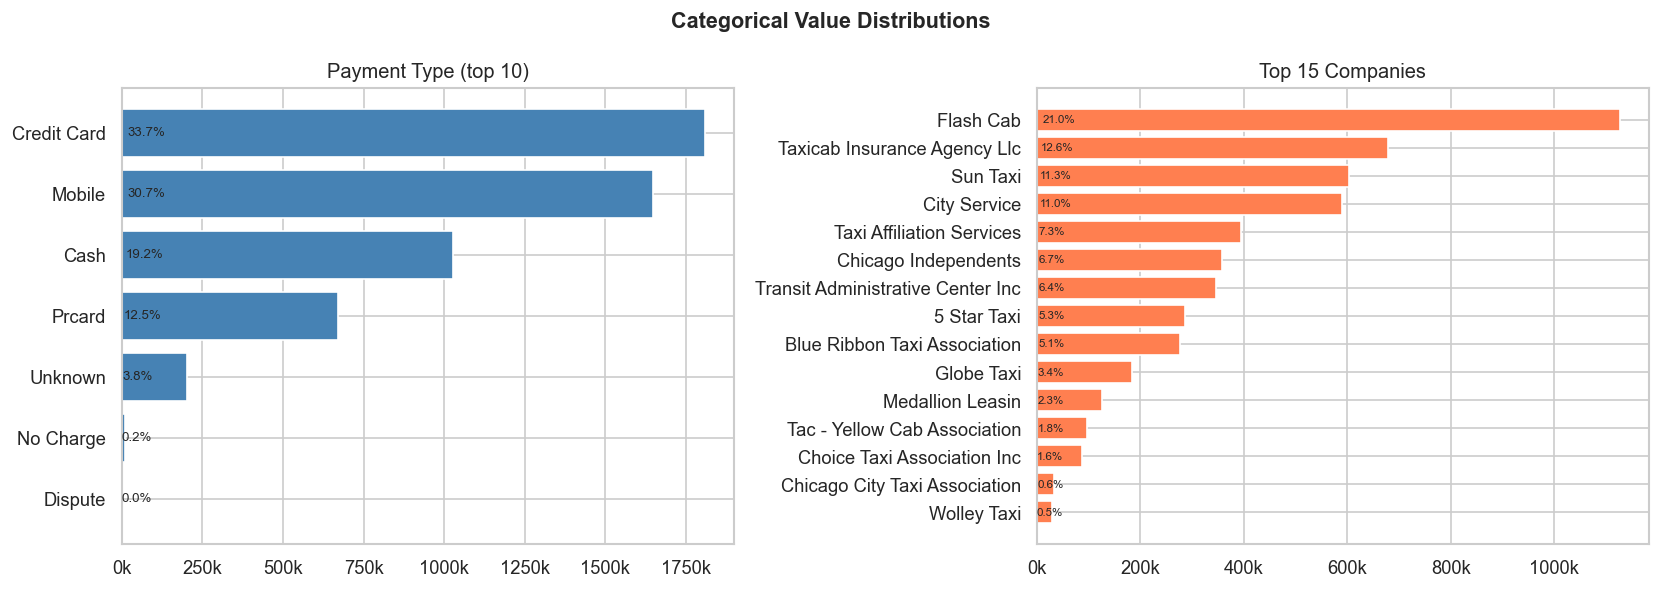


Tip rate by payment type (mean tip, % trips with tip > 0):
              mean_tip  pct_tipped        n
payment_type                               
Credit Card       5.54       92.92  1808340
Mobile            1.79       48.82  1647467
Prcard            0.10        2.15   671665
Unknown           0.00        0.12   202807
Dispute           0.00        0.07     1444
No Charge         0.00        0.03     8724
Cash              0.00        0.01  1028909


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment type
pt_plot = pt.head(10)
axes[0].barh(pt_plot.index[::-1], pt_plot.values[::-1], color="steelblue")
axes[0].set_title("Payment Type (top 10)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
for v, lbl in zip(pt_plot.values[::-1], pt_plot.index[::-1]):
    axes[0].text(v * 0.01, lbl, f"{v/n*100:.1f}%", va="center", fontsize=8)

# Company (top 15)
co_plot = co.head(15)
axes[1].barh(co_plot.index[::-1], co_plot.values[::-1], color="coral")
axes[1].set_title("Top 15 Companies")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
for v, lbl in zip(co_plot.values[::-1], co_plot.index[::-1]):
    axes[1].text(v * 0.01, lbl, f"{v/n*100:.1f}%", va="center", fontsize=7)

plt.suptitle("Categorical Value Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tips by payment type
print("\nTip rate by payment type (mean tip, % trips with tip > 0):")
tip_by_pt = df.groupby("payment_type").agg(
    mean_tip=("tips", "mean"),
    pct_tipped=("tips", lambda x: (x > 0).mean() * 100),
    n=("tips", "count"),
).sort_values("pct_tipped", ascending=False)
print(tip_by_pt.round(2).to_string())

## 7  Spatial Sanity Checks

In [17]:
# Chicago bounding box (approximate)
CHI_LAT = (41.60, 42.05)
CHI_LON = (-87.95, -87.50)

for side in ("pickup", "dropoff"):
    lat = df[f"{side}_centroid_latitude"].dropna()
    lon = df[f"{side}_centroid_longitude"].dropna()
    out_lat = ((lat < CHI_LAT[0]) | (lat > CHI_LAT[1])).sum()
    out_lon = ((lon < CHI_LON[0]) | (lon > CHI_LON[1])).sum()
    print(f"{side} lat range: [{lat.min():.4f}, {lat.max():.4f}]  — outside Chicago box: {out_lat:,}")
    print(f"{side} lon range: [{lon.min():.4f}, {lon.max():.4f}]  — outside Chicago box: {out_lon:,}")
    print()

# Community area range
for side in ("pickup", "dropoff"):
    ca = df[f"{side}_community_area"]
    outside_77 = ((ca < 1) | (ca > 77)).sum()
    print(f"{side}_community_area range: [{ca.min()}, {ca.max()}]  — outside 1-77: {outside_77:,}")
    na_ca = ca.isna().sum()
    print(f"  NaN: {na_ca:,}")
print()

# All 77 community areas covered?
all_cas = set(range(1, 78))
pu_cas = set(df["pickup_community_area"].dropna().astype(int).unique())
do_cas = set(df["dropoff_community_area"].dropna().astype(int).unique())
print(f"Pickup   CAs present: {len(pu_cas)}/77  — missing: {sorted(all_cas - pu_cas)}")
print(f"Dropoff  CAs present: {len(do_cas)}/77  — missing: {sorted(all_cas - do_cas)}")

pickup lat range: [41.6502, 42.0212]  — outside Chicago box: 0
pickup lon range: [-87.9136, -87.5314]  — outside Chicago box: 0

dropoff lat range: [41.6601, 42.0212]  — outside Chicago box: 0
dropoff lon range: [-87.9136, -87.5349]  — outside Chicago box: 0

pickup_community_area range: [1, 77]  — outside 1-77: 0
  NaN: 0
dropoff_community_area range: [1, 77]  — outside 1-77: 0
  NaN: 0

Pickup   CAs present: 77/77  — missing: []
Dropoff  CAs present: 77/77  — missing: []


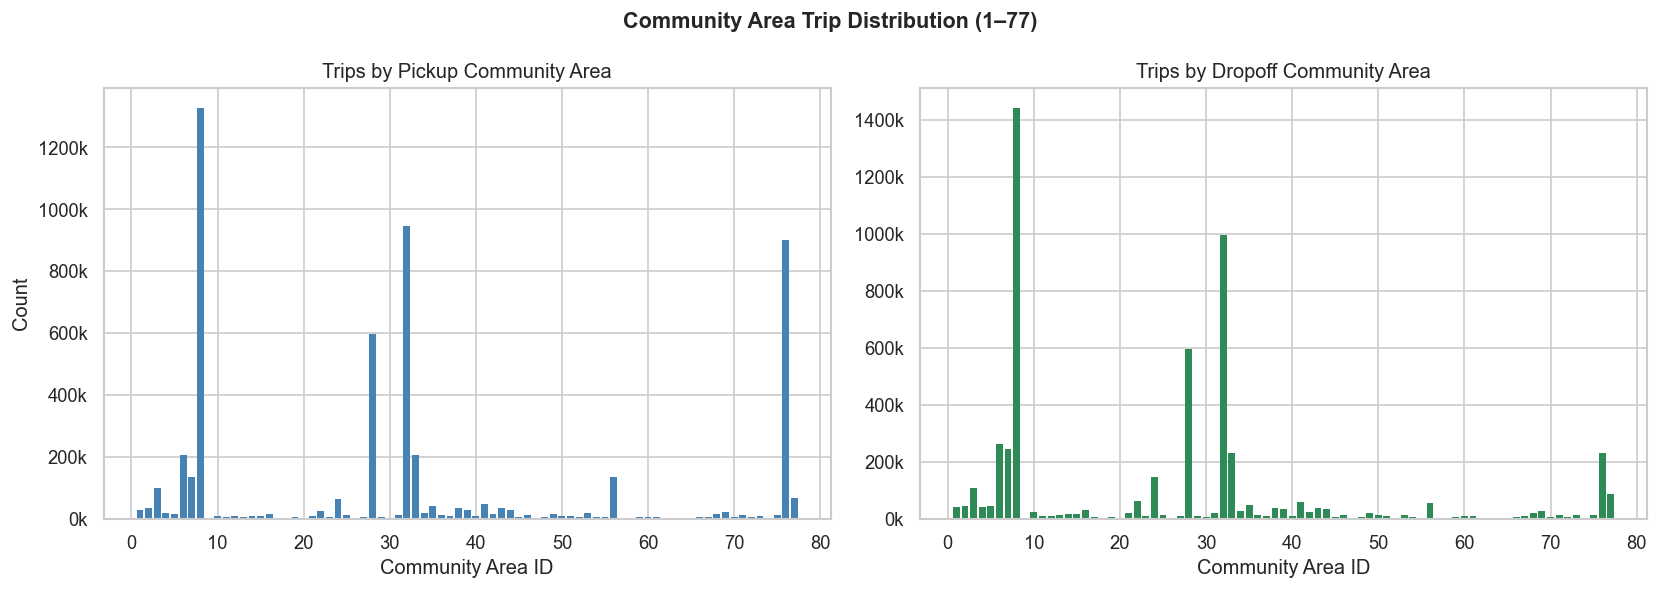

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pickup community area distribution
pu_ca_counts = df["pickup_community_area"].value_counts().sort_index()
axes[0].bar(pu_ca_counts.index, pu_ca_counts.values, width=0.8, color="steelblue", edgecolor="none")
axes[0].set_title("Trips by Pickup Community Area")
axes[0].set_xlabel("Community Area ID")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Dropoff community area distribution
do_ca_counts = df["dropoff_community_area"].value_counts().sort_index()
axes[1].bar(do_ca_counts.index, do_ca_counts.values, width=0.8, color="seagreen", edgecolor="none")
axes[1].set_title("Trips by Dropoff Community Area")
axes[1].set_xlabel("Community Area ID")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

plt.suptitle("Community Area Trip Distribution (1–77)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

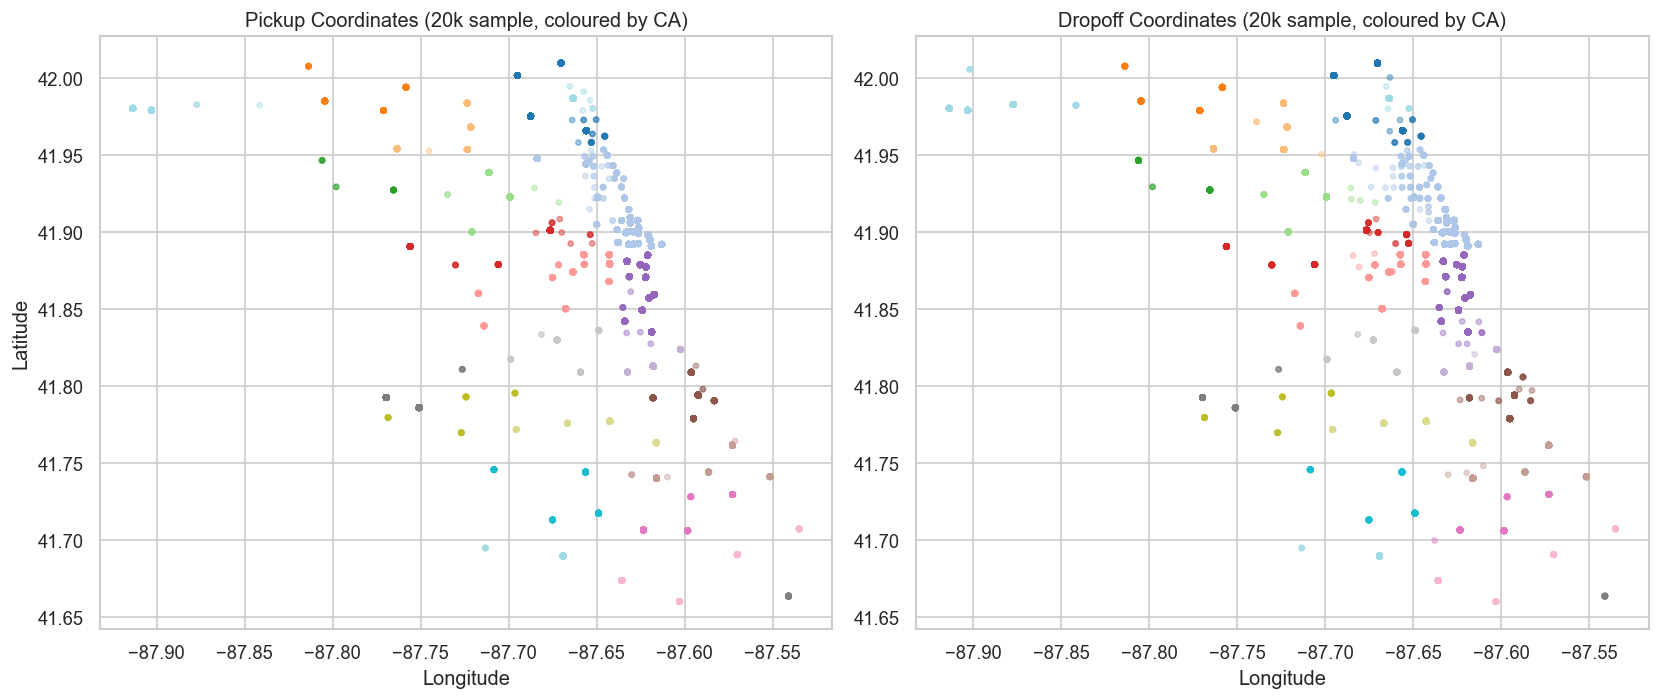

In [24]:
# Scatter: pickup coordinates coloured by community area (sample 20k for speed)
sample = df[df["pickup_centroid_latitude"].notna()].sample(min(20_000, n), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc = axes[0].scatter(sample["pickup_centroid_longitude"], sample["pickup_centroid_latitude"],
                     c=sample["pickup_community_area"], cmap="tab20", s=10, alpha=0.4)
axes[0].set_title("Pickup Coordinates (20k sample, coloured by CA)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sc2 = axes[1].scatter(sample["dropoff_centroid_longitude"], sample["dropoff_centroid_latitude"],
                      c=sample["dropoff_community_area"], cmap="tab20", s=10, alpha=0.4)
axes[1].set_title("Dropoff Coordinates (20k sample, coloured by CA)")
axes[1].set_xlabel("Longitude")
plt.tight_layout()
plt.show()

## 8  Taxi ID & Trip ID Checks

Unique trip_ids: 5,369,356  (total rows: 5,369,356)
Duplicate trip_ids: 0

Unique taxi_ids: 3,035

Trips per taxi:
count    3035.0
mean     1769.1
std      1186.6
min         1.0
1%         17.0
5%        232.0
25%       915.5
50%      1535.0
75%      2393.5
95%      4018.4
99%      5518.4
max      9521.0
dtype: float64

Taxis with only 1 trip: 4
Taxis with > 2000 trips: 1,043


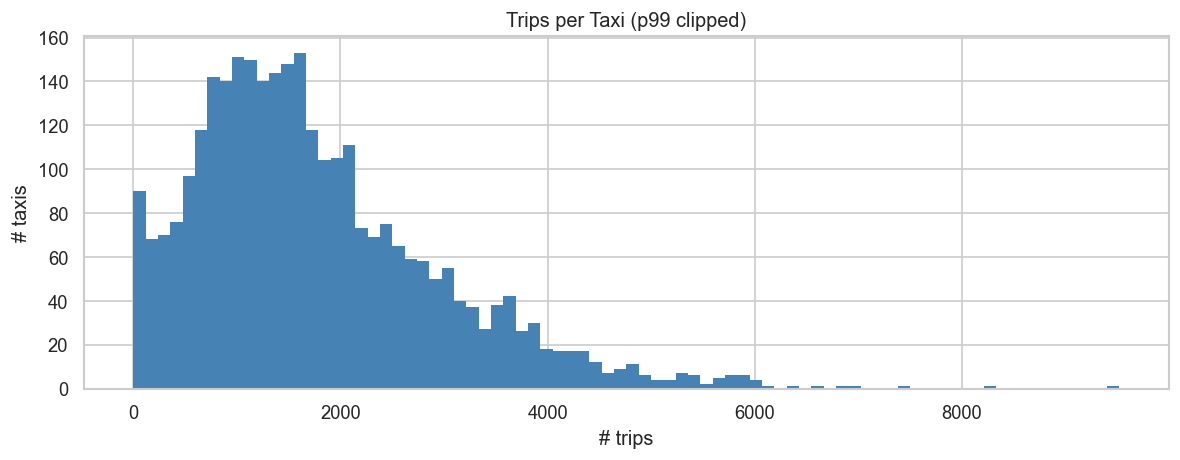

In [ ]:
print(f"Unique trip_ids: {df['trip_id'].nunique():,}  (total rows: {n:,})")
print(f"Duplicate trip_ids: {df['trip_id'].duplicated().sum():,}")
print()

n_taxis = df["taxi_id"].nunique()
print(f"Unique taxi_ids: {n_taxis:,}")

trips_per_taxi = df.groupby("taxi_id").size()
print(f"\nTrips per taxi:")
print(trips_per_taxi.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(1))

print(f"\nTaxis with only 1 trip: {(trips_per_taxi == 1).sum():,}")
print(f"Taxis with > 2000 trips: {(trips_per_taxi > 2000).sum():,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(trips_per_taxi, #.clip(upper=trips_per_taxi.quantile(0.99)), 
        bins=80,
        color="steelblue", edgecolor="none")
ax.set_title("Trips per Taxi")
ax.set_xlabel("# trips")
ax.set_ylabel("# taxis")
plt.tight_layout()
plt.show()

## 9  Price Anomalies

In [21]:
# Round fare values — Chicago taxi meter emits increments of $0.25
fare_rounded = (df["fare"] % 0.25 == 0).mean() * 100
print(f"Fares that are multiples of $0.25: {fare_rounded:.1f}%")

# Very low fares (< $3 — below Chicago minimum flag)
low_fare = df[df["fare"] < 3.0]
print(f"Trips with fare < $3.00: {len(low_fare):,}  ({len(low_fare)/n*100:.2f}%)")
print(low_fare[["fare", "trip_miles", "trip_seconds"]].describe().round(2))
print()

# Extreme fare values
print("Highest 10 fares:")
print(df.nlargest(10, "fare")[["fare", "trip_miles", "trip_seconds", "payment_type", "company"]].to_string())
print()

# Tolls distribution (should mostly be 0)
toll_non_zero = (df["tolls"] > 0).sum()
print(f"Trips with tolls > 0: {toll_non_zero:,}  ({toll_non_zero/n*100:.2f}%)")
print(df[df["tolls"] > 0]["tolls"].describe().round(2))
print()

# Extras distribution
extras_non_zero = (df["extras"] > 0).sum()
print(f"Trips with extras > 0: {extras_non_zero:,}  ({extras_non_zero/n*100:.2f}%)")
print(df["extras"].value_counts().head(15))

Fares that are multiples of $0.25: 78.5%
Trips with fare < $3.00: 0  (0.00%)
       fare  trip_miles  trip_seconds
count   0.0         0.0           0.0
mean    NaN         NaN           NaN
std     NaN         NaN           NaN
min     NaN         NaN           NaN
25%     NaN         NaN           NaN
50%     NaN         NaN           NaN
75%     NaN         NaN           NaN
max     NaN         NaN           NaN

Highest 10 fares:
          fare  trip_miles  trip_seconds payment_type                       company
3309479  76.58       17.80        1912.0  Credit Card          Chicago Independents
31245    76.50       31.45        2748.0  Credit Card  Taxicab Insurance Agency Llc
91846    76.50       30.99        3385.0         Cash                  City Service
111812   76.50       32.34        3202.0         Cash   Choice Taxi Association Inc
374943   76.50       28.93        3330.0         Cash                     Flash Cab
479179   76.50       31.06        2728.0         Cash  Tax

## 10  H3 Cell Checks

pickup_h3_res6: unique=33  na=0  empty_str=0
dropoff_h3_res6: unique=33  na=0  empty_str=0

pickup_h3_res7: unique=160  na=0  empty_str=0
dropoff_h3_res7: unique=160  na=0  empty_str=0

H3 res6 pickup cell trip counts (top 10 and stats):
pickup_h3_res6
862664c1fffffff    1934179
862664c17ffffff     832864
862664cafffffff     618943
86275934fffffff     365396
862759347ffffff     344054
862664d8fffffff     231599
862664cf7ffffff     193449
862664cc7ffffff     125938
862664527ffffff     125352
86275935fffffff     101605
Name: count, dtype: int64

count         33.0
mean      162708.0
std       368742.0
min            7.0
25%         6924.0
50%        26886.0
75%       125352.0
max      1934179.0
Name: count, dtype: float64


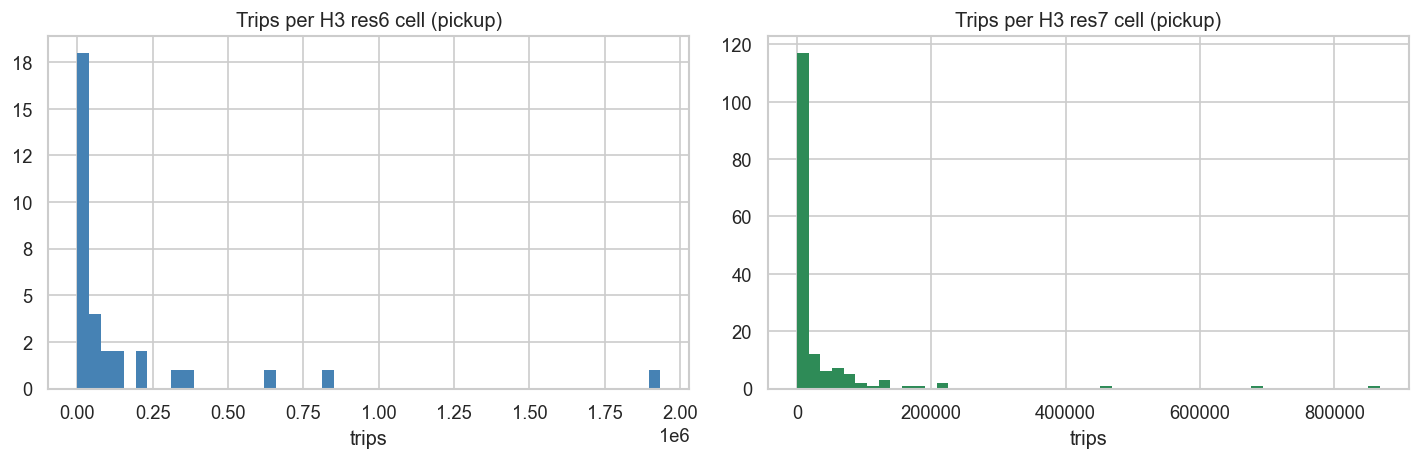

In [22]:
for res in ("res6", "res7"):
    for side in ("pickup", "dropoff"):
        col = f"{side}_h3_{res}"
        na = df[col].isna().sum()
        empty = (df[col].astype(str).str.strip() == "").sum()
        unique = df[col].nunique()
        print(f"{col}: unique={unique:,}  na={na:,}  empty_str={empty:,}")
    print()

# H3 res6 trip distribution across cells (should not be wildly skewed)
print("H3 res6 pickup cell trip counts (top 10 and stats):")
h3_res6_counts = df["pickup_h3_res6"].value_counts()
print(h3_res6_counts.head(10))
print()
print(h3_res6_counts.describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(h3_res6_counts.values, bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Trips per H3 res6 cell (pickup)")
axes[0].set_xlabel("trips")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

h3_res7_counts = df["pickup_h3_res7"].value_counts()
axes[1].hist(h3_res7_counts.values, bins=50, color="seagreen", edgecolor="none")
axes[1].set_title("Trips per H3 res7 cell (pickup)")
axes[1].set_xlabel("trips")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## 11  Notable Edge Cases Summary

In [23]:
findings = []

# 1. trip_total != fare+tips+tolls+extras
n_mismatch = (df["total_diff"].abs() > 0.05).sum()
findings.append(("trip_total mismatch > $0.05", n_mismatch, n_mismatch/n*100,
                 "trip_total does not equal fare+tips+tolls+extras"))

# 2. end timestamp == start timestamp (but trip_seconds > 0)
n_same_ts = ((df["trip_end_timestamp"] == df["trip_start_timestamp"]) & (df["trip_seconds"] > 0)).sum()
findings.append(("end_ts == start_ts but seconds>0", n_same_ts, n_same_ts/n*100,
                 "Timestamps rounded to same 15-min bucket; trip_seconds is the reliable duration"))

# 3. Trips ending in 2026
n_2026 = (df["trip_end_timestamp"].dt.year == 2026).sum()
findings.append(("trip_end in 2026", n_2026, n_2026/n*100,
                 "Dec-31 trips that naturally end in 2026 — OK but worth noting"))

# 4. Speed > 80 mph
n_fast = (df["speed_mph"] > 80).sum()
findings.append(("speed > 80 mph", n_fast, n_fast/n*100,
                 "Implausibly fast for city driving; possible meter error or GPS snap"))

# 5. Same exact coords but trip_miles > 0
n_same_c = len(same_coords)
findings.append(("same coords but miles>0", n_same_c, n_same_c/n*100,
                 "Coordinates are centroid-snapped to census tract; not a GPS trace"))

# 6. tip > fare
n_tip_fare = len(tip_gt_fare)
findings.append(("tip > fare", n_tip_fare, n_tip_fare/n*100,
                 "Unusually large tip; check payment_type breakdown"))

# 7. Missing coordinates (dropoff)
n_coord_na = df["dropoff_centroid_latitude"].isna().sum()
findings.append(("dropoff coords missing", n_coord_na, n_coord_na/n*100,
                 "Only community area known; no lat/lon for dropoff"))

# 8. fare < $3
n_low = len(low_fare)
findings.append(("fare < $3", n_low, n_low/n*100,
                 "Below typical Chicago taxi minimum; may be flat-rate or partial trips"))

report = pd.DataFrame(findings, columns=["Issue", "Count", "% of rows", "Notes"])
report["Count"] = report["Count"].apply(lambda x: f"{int(x):,}")
report["% of rows"] = report["% of rows"].apply(lambda x: f"{x:.3f}%")
print(report.to_string(index=False))

                           Issue     Count % of rows                                                                           Notes
     trip_total mismatch > $0.05 3,016,169   56.174%                                trip_total does not equal fare+tips+tolls+extras
end_ts == start_ts but seconds>0 1,042,361   19.413% Timestamps rounded to same 15-min bucket; trip_seconds is the reliable duration
                trip_end in 2026        72    0.001%                   Dec-31 trips that naturally end in 2026 — OK but worth noting
                  speed > 80 mph       187    0.003%             Implausibly fast for city driving; possible meter error or GPS snap
         same coords but miles>0   348,203    6.485%               Coordinates are centroid-snapped to census tract; not a GPS trace
                      tip > fare     8,090    0.151%                               Unusually large tip; check payment_type breakdown
          dropoff coords missing         0    0.000%                 

---
### Key Takeaways

| # | Finding | Action |
|---|---------|--------|
| 1 | **trip_total ≠ fare+tips+tolls+extras** for a fraction of rows | Use component columns individually; avoid relying on `trip_total` as a derived check |
| 2 | **Timestamps are 15-min bucketed** — many trips have `end == start` even with non-zero `trip_seconds` | Always use `trip_seconds` for duration, not timestamp subtraction |
| 3 | **Trips ending in 2026** (Dec-31 late-night) | Filter by `trip_start_timestamp` year if doing annual aggregations |
| 4 | **Coordinates are census-tract centroids**, not GPS — same pickup/dropoff coords can mean different locations inside the same tract | Don't treat coordinate distance as actual trip displacement |
| 5 | **Significant missing dropoff coordinates** (~10%) | Community area is complete; use that for spatial joins, not raw coords |
| 6 | **Speed > 80 mph** present after z-score cleaning | If speed matters (e.g. congestion analysis), add an explicit mph cap |
| 7 | **tip > fare** cases exist and are mostly credit card / mobile | Legitimate but worth knowing when computing tip rates |
| 8 | **fare < $3** trips remain after cleaning | May reflect short airport-queue or hotel driveway pickups billed at minimum |